# ClickTheLook: DeepFashion2 YOLO Training Pipeline
## S3 Batch-Fetching + Memory-Safe Training on NEU HPC

### How this pipeline manages memory and disk

```
CONVERSION PHASE (batched — keeps RAM bounded):
┌────────────────────────────────────────────────────────────┐
│  For each CSV chunk (5,000 rows):                          │
│    1. Stream chunk of metadata from S3 → RAM (~50 MB)      │
│    2. Download only that chunk's images from S3 → scratch  │
│    3. Convert annotations to YOLO .txt labels on scratch   │
│    4. Free the chunk DataFrame from RAM                    │
│    5. Repeat until entire CSV is processed                 │
│    ★ Disk space checked before each batch — stops safely   │
│      if scratch fills up                                   │
└────────────────────────────────────────────────────────────┘

TRAINING PHASE (YOLO handles memory automatically):
┌────────────────────────────────────────────────────────────┐
│  model.train() reads images from scratch disk on-the-fly   │
│  Only batch_size images (e.g. 16) are in GPU memory at     │
│  any time — the full dataset is NEVER loaded into RAM.     │
│  This is how PyTorch DataLoader works by default.          │
└────────────────────────────────────────────────────────────┘
```

### Why NOT stream-and-discard during training?
- YOLO's `model.train()` needs proper dataset shuffling across ALL images for convergence
- Training on isolated chunks would hurt model quality (no global shuffle, biased batches)
- PyTorch DataLoader already handles RAM efficiently — only batch_size images in memory
- The bottleneck was conversion (large CSV), not training

### Sections
1. Setup & Configuration
2. S3 Connection & Verification
3. S3 Batch Data Utilities
4. Data Exploration (streamed from S3)
5. Batch Conversion: S3 → YOLO Format on Scratch
6. Model Training (standard YOLO — memory-safe by design)
7. Evaluation
8. Inference
9. Export & Upload Weights to S3
10. Cleanup

---
## 1. Setup and Configuration

In [1]:
import os, gc, json, time, shutil, random
from pathlib import Path
from ast import literal_eval
from typing import List, Dict, Tuple, Optional, Generator
from io import BytesIO, StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm
import cv2
import yaml
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch: {torch.__version__}")

All libraries imported successfully!
PyTorch: 2.0.1+cu118


In [2]:
print("GPU Status:")
print(f"  CUDA Available: {torch.cuda.is_available()}")
print(f"  GPU Count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name} ({props.total_memory / 1024**3:.1f} GB)")
    DEVICE = 0
else:
    print("  WARNING: No GPU detected.")
    DEVICE = "cpu"

print(f"\nUsing device: {DEVICE}")

GPU Status:
  CUDA Available: True
  GPU Count: 1
  GPU 0: Tesla P100-PCIE-12GB (11.9 GB)

Using device: 0


In [3]:
SCRATCH_DATA_ROOT = "/scratch/shah.parin2/DeepFashion2"      # raw dataset
SCRATCH_ROOT      = "/scratch/shah.parin2/ClickTheLook" 

LOCAL_PATHS = {
    "train_csv":    os.path.join(SCRATCH_DATA_ROOT, "img_info_dataframes", "train.csv"),
    "val_csv":      os.path.join(SCRATCH_DATA_ROOT, "img_info_dataframes", "validation.csv"),
    "train_images": os.path.join(SCRATCH_DATA_ROOT, "deepfashion2_original_images", "train", "image"),
    "val_images":   os.path.join(SCRATCH_DATA_ROOT, "deepfashion2_original_images", "validation", "image"),
}

YOLO_DATASET_DIR = os.path.join(SCRATCH_ROOT, "yolo_dataset")
TRAINING_OUTPUT_DIR = os.path.join(SCRATCH_ROOT, "runs")

CSV_BATCH_SIZE = 20000
IMAGE_DOWNLOAD_BATCH = 200       # kept for chunk progress; symlinks make it instant
MIN_DISK_FREE_GB = 5.0

CATEGORIES = {
    1: "short_sleeve_top", 2: "long_sleeve_top",
    3: "short_sleeve_outwear", 4: "long_sleeve_outwear",
    5: "vest", 6: "sling", 7: "shorts", 8: "trousers",
    9: "skirt", 10: "short_sleeve_dress", 11: "long_sleeve_dress",
    12: "vest_dress", 13: "sling_dress"
}
NUM_CLASSES = len(CATEGORIES)


TRAINING_CONFIG = {
    "model":            "yolov8n.pt",
    "epochs":           13,             # keep original, can reduce for quick tests
    "batch":            96,             # increase to better utilize GPU memory
    "imgsz":            640,            # smaller images → faster training
    "patience":         10,
    "freeze":           10,             # keep backbone frozen
    "optimizer":        "AdamW",
    "lr0":              0.01,
    "lrf":              0.1,
    "momentum":         0.937,
    "weight_decay":     0.0005,
    "warmup_epochs":    1.0,
    "warmup_momentum":  0.8,
    "warmup_bias_lr":   0.1,
    "cos_lr":           True,
    "label_smoothing":  0.1,
    
    # -- Data Augmentation --
    "hsv_h":            0.015,
    "hsv_s":            0.2,            # reduce saturation shift
    "hsv_v":            0.2,            # reduce brightness shift
    "degrees":          5.0,            # smaller rotation
    "translate":        0.05,           # smaller translation
    "scale":            0.2,            # smaller scale changes
    "shear":            0.0,
    "perspective":      0.0,
    "flipud":           0.0,
    "fliplr":           0.5,
    "mosaic":           0.5,            # partial mosaic
    "mixup":            0.0,
    "amp":              True,           # keep Automatic Mixed Precision
    
    # -- Performance / Hardware --
    # "rect":             True,
    "device":           0,
    "workers":          4,              # more dataloader workers
    "cache":            "disk",         # cache dataset in RAM for speed
    
    # -- Output & logging --
    "project":          TRAINING_OUTPUT_DIR,
    "name":             "yolov8_deepfashion2",
    "exist_ok":         True,
    "pretrained":       True,
    "verbose":          True,
    "val":              False,          # skip validation for faster epoch iteration
}

gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"Using {TRAINING_CONFIG['cache']} for cache.")
print(f"Batch size is {TRAINING_CONFIG['batch']} for {gpu_mem:.0f} GB GPU")

if torch.cuda.device_count() > 1:
    TRAINING_CONFIG["device"] = list(range(torch.cuda.device_count()))
    TRAINING_CONFIG["batch"] *= torch.cuda.device_count()
    print(f"Multi-GPU: {torch.cuda.device_count()} GPUs, batch={TRAINING_CONFIG['batch']}")

for d in [YOLO_DATASET_DIR, TRAINING_OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"\nData root  : {SCRATCH_DATA_ROOT}")
print(f"Scratch    : {SCRATCH_ROOT}")
print(f"CSV Batch  : {CSV_BATCH_SIZE:,} | Image Batch: {IMAGE_DOWNLOAD_BATCH}")
print(f"Min Free Disk: {MIN_DISK_FREE_GB} GB")
print(f"Classes    : {NUM_CLASSES}")

Using disk for cache.
Batch size is 96 for 12 GB GPU

Data root  : /scratch/shah.parin2/DeepFashion2
Scratch    : /scratch/shah.parin2/ClickTheLook
CSV Batch  : 20,000 | Image Batch: 200
Min Free Disk: 5.0 GB
Classes    : 13


---
## 2. Path Verification

In [4]:
def verify_local_paths():
    print("Verifying scratch paths...")
    print("=" * 60)
    ok = True
    for name, path in LOCAL_PATHS.items():
        exists = os.path.exists(path)
        print(f"  {'✓' if exists else '✗ MISSING'} {name}: {path}")
        if not exists:
            ok = False
    print("=" * 60)
    return ok

verify_local_paths()

Verifying scratch paths...
  ✓ train_csv: /scratch/shah.parin2/DeepFashion2/img_info_dataframes/train.csv
  ✓ val_csv: /scratch/shah.parin2/DeepFashion2/img_info_dataframes/validation.csv
  ✓ train_images: /scratch/shah.parin2/DeepFashion2/deepfashion2_original_images/train/image
  ✓ val_images: /scratch/shah.parin2/DeepFashion2/deepfashion2_original_images/validation/image


True

---
## 3. S3 Batch Data Utilities

In [5]:
def get_disk_free_gb(path: str) -> float:
    stat = os.statvfs(path)
    return (stat.f_bavail * stat.f_frsize) / (1024 ** 3)

free = get_disk_free_gb(SCRATCH_ROOT)
print(f"Scratch free space: {free:.1f} GB")
if free < MIN_DISK_FREE_GB:
    print(f"  ⚠ Below minimum ({MIN_DISK_FREE_GB} GB)!")
elif free < 50:
    print(f"  Pipeline will stop gracefully if disk fills up.")
else:
    print(f"  Plenty of space.")


Scratch free space: 899756.8 GB
  Plenty of space.


In [6]:
class ScratchDataLoader:
    """
    Memory-efficient data loader that reads from the scratch filesystem.
    Drop-in replacement for S3BatchDataLoader.

    - CSV metadata is streamed in chunks (bounded RAM)
    - Images are symlinked per-chunk (zero extra disk space)
    - Disk space checked before each batch (safe stop)
    """

    def __init__(self, csv_batch_size=20000, image_batch=200, min_disk_free_gb=5.0):
        self.csv_batch_size   = csv_batch_size
        self.image_batch      = image_batch
        self.min_disk_free_gb = min_disk_free_gb

    # Now: open local file path directly. Same chunk-yield interface.
    def stream_csv_batches(self, csv_path: str):
        """Read local CSV in chunks; yield (batch_num, DataFrame)."""
        print(f"  Reading CSV: {csv_path}")
        size_mb = os.path.getsize(csv_path) / 1024**2
        total_rows = sum(1 for _ in open(csv_path)) - 1  # fast line count
        total_batches = (total_rows // self.csv_batch_size) + 1
        print(f"  CSV size: {size_mb:.1f} MB | ~{total_rows:,} rows | {total_batches} batches")
    
        batch_num = 0
        for chunk in tqdm(
            pd.read_csv(csv_path, chunksize=self.csv_batch_size),
            total=total_batches,
            desc="  CSV batches",
            unit="batch",
        ):
            batch_num += 1
            yield batch_num, chunk
    
        print(f"  Streamed {batch_num} CSV batches")

    # Now: pd.read_csv with a plain file path.
    def load_csv(self, csv_path: str) -> pd.DataFrame:
        """Load full CSV into DataFrame (for exploration)."""
        print(f"  Loading: {csv_path}")
        df = pd.read_csv(csv_path)
        print(f"  Loaded {len(df):,} rows ({df.memory_usage(deep=True).sum()/1024**2:.1f} MB)")
        return df

    # Now: os.listdir on a local directory, return {filename: full_path}.
    def build_image_index(self, images_dir: str) -> Dict[str, str]:
        """Return {filename: full_path} for all images in a directory."""
        print(f"  Indexing: {images_dir}")
        index = {
            fname: os.path.join(images_dir, fname)
            for fname in os.listdir(images_dir)
            if fname.lower().endswith((".jpg", ".jpeg", ".png"))
        }
        print(f"  Found {len(index):,} images")
        return index

    # os.symlink() — pointer to the existing scratch file.
    #   • Instant (no I/O)
    #   • No extra disk usage (important on shared scratch)
    #   • Disk-space safety check retained [UNCHANGED]
    def link_images(self, filenames: List[str], src_index: Dict[str, str],
                    dest_dir: str) -> Tuple[int, bool]:
        """
        Symlink images into dest_dir.
        Returns (count_linked, disk_ok) — same signature as original download_images.
        """
        os.makedirs(dest_dir, exist_ok=True)
        linked = 0

        to_link = [
            fn for fn in filenames
            if fn in src_index and not os.path.exists(os.path.join(dest_dir, fn))
        ]

        for i in range(0, len(to_link), self.image_batch):
            free_gb = get_disk_free_gb(SCRATCH_ROOT)
            if free_gb < self.min_disk_free_gb:
                print(f"\n  ⚠ Disk low ({free_gb:.1f} GB). Stopping.")
                return linked, False

            for fn in to_link[i : i + self.image_batch]:
                dest = os.path.join(dest_dir, fn)
                try:
                    os.symlink(src_index[fn], dest)
                    linked += 1
                except OSError as e:
                    print(f"  Warning: {fn}: {e}")

        return linked, True


loader = ScratchDataLoader(
    csv_batch_size=CSV_BATCH_SIZE,
    image_batch=IMAGE_DOWNLOAD_BATCH,
    min_disk_free_gb=MIN_DISK_FREE_GB,
)
print("ScratchDataLoader ready.")

ScratchDataLoader ready.


---
## 4. Data Exploration (Streamed from S3)

Loading training metadata from scratch...
  Loading: /scratch/shah.parin2/DeepFashion2/img_info_dataframes/train.csv
  Loaded 312,186 rows (348.8 MB)
Shape: (312186, 12)

TRAIN SPLIT
Total annotations: 312,186
Unique images: 191,961 | Avg annot/img: 1.6
   1. short_sleeve_top         :  71,645 ( 22.9%)
   2. long_sleeve_top          :  36,064 ( 11.6%)
   3. short_sleeve_outwear     :     543 (  0.2%)
   4. long_sleeve_outwear      :  13,457 (  4.3%)
   5. vest                     :  16,095 (  5.2%)
   6. sling                    :   1,985 (  0.6%)
   7. shorts                   :  36,616 ( 11.7%)
   8. trousers                 :  55,387 ( 17.7%)
   9. skirt                    :  30,835 (  9.9%)
  10. short_sleeve_dress       :  17,211 (  5.5%)
  11. long_sleeve_dress        :   7,907 (  2.5%)
  12. vest_dress               :  17,949 (  5.7%)
  13. sling_dress              :   6,492 (  2.1%)


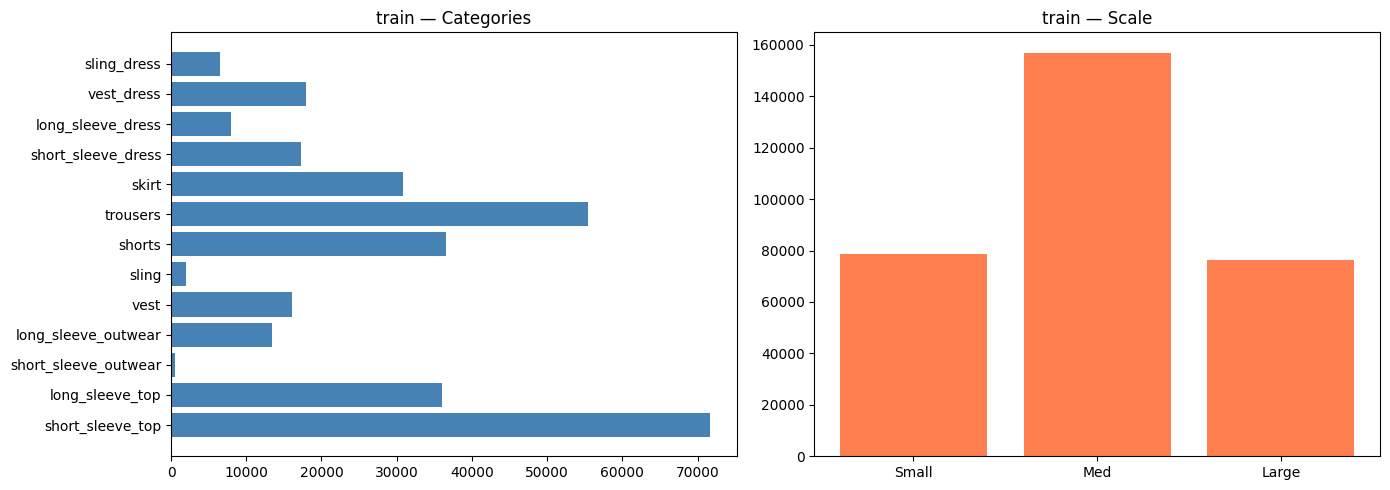

Loading validation metadata...
  Loading: /scratch/shah.parin2/DeepFashion2/img_info_dataframes/validation.csv
  Loaded 52,490 rows (216.2 MB)

VALIDATION SPLIT
Total annotations: 52,490
Unique images: 32,153 | Avg annot/img: 1.6
   1. short_sleeve_top         :  12,556 ( 23.9%)
   2. long_sleeve_top          :   5,966 ( 11.4%)
   3. short_sleeve_outwear     :     142 (  0.3%)
   4. long_sleeve_outwear      :   2,011 (  3.8%)
   5. vest                     :   2,113 (  4.0%)
   6. sling                    :     322 (  0.6%)
   7. shorts                   :   4,167 (  7.9%)
   8. trousers                 :   9,586 ( 18.3%)
   9. skirt                    :   6,522 ( 12.4%)
  10. short_sleeve_dress       :   3,127 (  6.0%)
  11. long_sleeve_dress        :   1,477 (  2.8%)
  12. vest_dress               :   3,352 (  6.4%)
  13. sling_dress              :   1,149 (  2.2%)


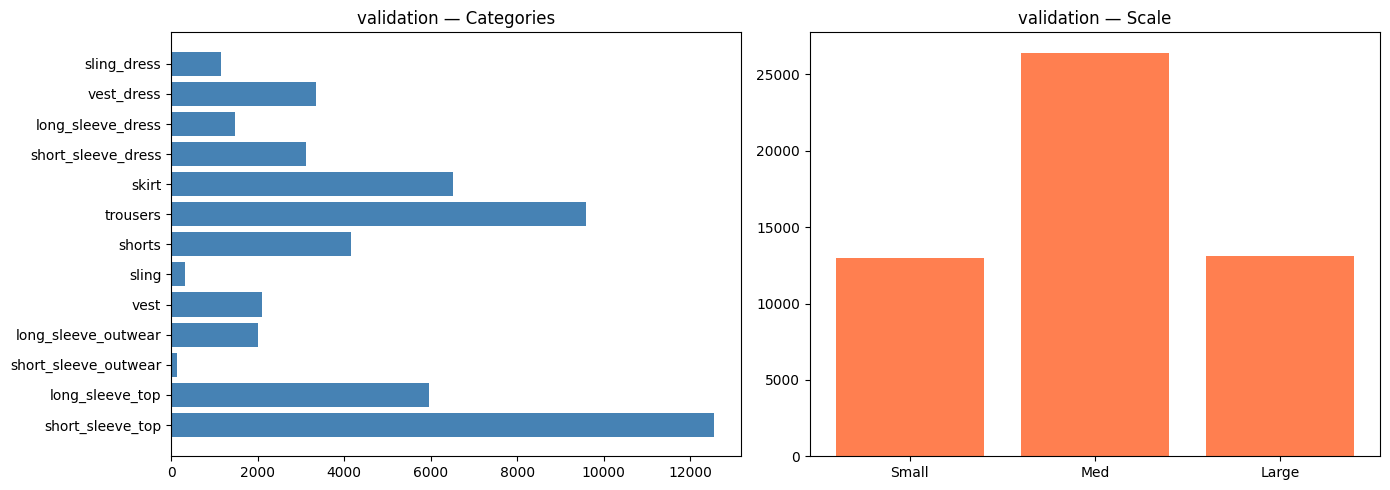

In [7]:
def analyze_metadata(df, split_name):
    print(f"\n{'='*60}\n{split_name.upper()} SPLIT\n{'='*60}")
    print(f"Total annotations: {len(df):,}")
    if "path" in df.columns:
        u = df["path"].nunique()
        print(f"Unique images: {u:,} | Avg annot/img: {len(df)/u:.1f}")
    cat_counts = df["category_id"].value_counts().sort_index()
    for cid, cnt in cat_counts.items():
        print(f"  {cid:2d}. {CATEGORIES.get(cid,'?'):25s}: {cnt:>7,} ({cnt/len(df)*100:5.1f}%)")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(
        [CATEGORIES.get(i,"?") for i in cat_counts.index],
        cat_counts.values, color="steelblue"
    )
    axes[0].set_title(f"{split_name} — Categories")
    if "scale" in df.columns:
        sc = df["scale"].value_counts().sort_index()
        axes[1].bar(
            [{1:"Small",2:"Med",3:"Large"}.get(s,str(s)) for s in sc.index],
            sc.values, color="coral"
        )
        axes[1].set_title(f"{split_name} — Scale")
    plt.tight_layout(); plt.show()

print("Loading training metadata from scratch...")
train_df = loader.load_csv(LOCAL_PATHS["train_csv"])
print(f"Shape: {train_df.shape}")
train_df.head()

analyze_metadata(train_df, "train")

print("Loading validation metadata...")
val_df = loader.load_csv(LOCAL_PATHS["val_csv"])
analyze_metadata(val_df, "validation")

In [8]:
del train_df, val_df
gc.collect()
print("Freed exploration DataFrames.")

Freed exploration DataFrames.


---
## 5. Batch Conversion: S3 → YOLO Format on Scratch

For each CSV chunk:
1. Parse annotations (in RAM, ~50 MB)
2. Download that chunk's images from S3 → scratch
3. Write YOLO `.txt` labels → scratch
4. Free chunk from RAM
5. Check disk — stop if full

After this, all data lives on scratch disk. Training reads from disk on-the-fly.

In [9]:
def convert_bbox_to_yolo(bbox_str, img_w, img_h):
    try:
        bbox = literal_eval(bbox_str) if isinstance(bbox_str, str) else bbox_str
        x1, y1, x2, y2 = bbox
        x1, x2 = max(0, min(x1, img_w)), max(0, min(x2, img_w))
        y1, y2 = max(0, min(y1, img_h)), max(0, min(y2, img_h))
        w, h = (x2-x1)/img_w, (y2-y1)/img_h
        if w <= 0 or h <= 0: return None
        return [((x1+x2)/2)/img_w, ((y1+y2)/2)/img_h, w, h]
    except: return None

In [10]:
def convert_split_from_scratch(split, csv_path, images_dir):
    img_dir = os.path.join(YOLO_DATASET_DIR, "images", split)
    lbl_dir = os.path.join(YOLO_DATASET_DIR, "labels", split)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    stats = dict(total=0, converted=0, skipped=0, linked=0,
                 cached=0, labels=0, batches=0, disk_stop=False)

    src_index = loader.build_image_index(images_dir)

    print(f"\nConverting {split} in batches...")
    print("=" * 60)

    for batch_num, chunk_df in loader.stream_csv_batches(csv_path):
        stats["batches"] = batch_num
        t0 = time.time()

        fnames = [os.path.basename(p) for p in chunk_df["path"].unique()]
        cached = sum(1 for fn in fnames if os.path.exists(os.path.join(img_dir, fn)))
        stats["cached"] += cached

        n_linked, disk_ok = loader.link_images(fnames, src_index, img_dir)
        stats["linked"] += n_linked

        if not disk_ok:
            stats["disk_stop"] = True
            print(f"  Batch {batch_num}: DISK FULL — stopping. Will train on partial data.")
            del chunk_df; gc.collect()
            break

        # Annotation conversion
        for path, group in chunk_df.groupby("path"):
            fn = os.path.basename(path)
            if not os.path.exists(os.path.join(img_dir, fn)):
                stats["skipped"] += len(group); continue

            lines = []
            for _, row in group.iterrows():
                stats["total"] += 1
                cid = int(row["category_id"]) - 1
                if cid < 0 or cid >= NUM_CLASSES:
                    stats["skipped"] += 1; continue
                yolo = convert_bbox_to_yolo(
                    row["b_box"],
                    int(row.get("img_width", 640)),
                    int(row.get("img_height", 640)),
                )
                if yolo is None:
                    stats["skipped"] += 1; continue
                lines.append(
                    f"{cid} {yolo[0]:.6f} {yolo[1]:.6f} {yolo[2]:.6f} {yolo[3]:.6f}"
                )
                stats["converted"] += 1

            if lines:
                lbl_path = os.path.join(lbl_dir, os.path.splitext(fn)[0] + ".txt")
                mode = "a" if os.path.exists(lbl_path) else "w"
                with open(lbl_path, mode) as f:
                    f.write("\n".join(lines) + "\n")
                stats["labels"] += 1

        free = get_disk_free_gb(SCRATCH_ROOT)
        print(
            f"  Batch {batch_num}: {len(chunk_df):,} annot | "
            f"+{n_linked} linked | {time.time()-t0:.1f}s | {free:.1f} GB free"
        )
        del chunk_df; gc.collect()

    print(f"\n{'='*60}")
    print(
        f"{split.upper()} DONE — {stats['converted']:,}/{stats['total']:,} annotations, "
        f"{stats['linked']:,} linked, {stats['labels']:,} label files"
    )
    if stats["disk_stop"]:
        print("  ⚠ Stopped early due to disk space. Training will use partial data.")
    print("=" * 60)
    return stats

In [11]:
# print("PHASE: Converting training data (scratch → YOLO format)\n")
# train_stats = convert_split_from_scratch(
#     "train", LOCAL_PATHS["train_csv"], LOCAL_PATHS["train_images"]
# )

In [12]:
# print("\nPHASE: Converting validation data (scratch → YOLO format)\n")
# val_stats = convert_split_from_scratch(
#     "val", LOCAL_PATHS["val_csv"], LOCAL_PATHS["val_images"]
# )

In [13]:
print("\nYOLO dataset on scratch:")
for split in ["train", "val"]:
    idir = os.path.join(YOLO_DATASET_DIR, "images", split)
    ldir = os.path.join(YOLO_DATASET_DIR, "labels", split)
    ni = len([f for f in os.listdir(idir) if f.endswith((".jpg",".jpeg",".png"))]) if os.path.exists(idir) else 0
    nl = len([f for f in os.listdir(ldir) if f.endswith(".txt")]) if os.path.exists(ldir) else 0
    print(f"  {split}: {ni:,} images, {nl:,} labels")

print(f"\nDisk free: {get_disk_free_gb(SCRATCH_ROOT):.1f} GB")


YOLO dataset on scratch:
  train: 191,961 images, 191,961 labels
  val: 32,153 images, 32,153 labels

Disk free: 899758.3 GB


In [14]:
# Create YOLO YAML config
class_names = [CATEGORIES[i+1] for i in range(NUM_CLASSES)]
yaml_config = {
    "path":  YOLO_DATASET_DIR,
    "train": "images/train",
    "val":   "images/val",
    "nc":    NUM_CLASSES,
    "names": class_names,
}
yaml_path = os.path.join(YOLO_DATASET_DIR, "dataset.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(yaml_config, f, default_flow_style=False)
print(f"YAML: {yaml_path}")
with open(yaml_path) as f: print(f.read())

YAML: /scratch/shah.parin2/ClickTheLook/yolo_dataset/dataset.yaml
names:
- short_sleeve_top
- long_sleeve_top
- short_sleeve_outwear
- long_sleeve_outwear
- vest
- sling
- shorts
- trousers
- skirt
- short_sleeve_dress
- long_sleeve_dress
- vest_dress
- sling_dress
nc: 13
path: /scratch/shah.parin2/ClickTheLook/yolo_dataset
train: images/train
val: images/val



---
## 6. Model Training

**Memory is safe here by design.** YOLO's `model.train()` uses a PyTorch DataLoader that reads images from disk on-the-fly. Only `batch_size` images (e.g. 16) are in GPU memory at any time. The full dataset on scratch is **never** loaded into RAM all at once.

In [15]:
from ultralytics import YOLO
print(f"Ultralytics: {__import__('ultralytics').__version__}")

Ultralytics: 8.2.0


In [16]:
model = YOLO(TRAINING_CONFIG['model'])
print(f"Loaded: {TRAINING_CONFIG['model']}")

Loaded: yolov8n.pt


In [17]:
print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print(f"Dataset : {yaml_path}")
print(f"Device  : {TRAINING_CONFIG['device']}")
print(f"Batch   : {TRAINING_CONFIG['batch']}")
print()

params = {k: v for k, v in TRAINING_CONFIG.items() if k != "model"}
results = model.train(data=yaml_path, **params)
print("\nTraining complete!")

STARTING TRAINING
Dataset : /scratch/shah.parin2/ClickTheLook/yolo_dataset/dataset.yaml
Device  : 0
Batch   : 96

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (Tesla P100-PCIE-12GB, 12194MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/scratch/shah.parin2/ClickTheLook/yolo_dataset/dataset.yaml, epochs=13, time=None, patience=10, batch=96, imgsz=640, save=True, save_period=-1, cache=disk, device=0, workers=4, project=/scratch/shah.parin2/ClickTheLook/runs, name=yolov8_deepfashion2, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=10, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=False, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, ha

train: Scanning /scratch/shah.parin2/ClickTheLook/yolo_dataset/labels/train.cache... 191961 images, 0 backgrounds, 0 corrupt: 100%|██████████| 191961/191961 [00:00<?, ?it/s]IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)


train: Caching images (255.6GB Disk): 100%|██████████| 191961/191961 [00:16<00:00, 11866.78it/s]
val: Scanning /scratch/shah.parin2/ClickTheLook/yolo_dataset/labels/val.cache... 32153 images, 0 backgrounds, 0 corrupt: 100%|██████████| 32153/32153 [00:00<?, ?it/s]
val: Caching images (41.6GB Disk): 100%|██████████| 32153/32153 [00:00<00:00, 42216.09it/s]


Plotting labels to /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/labels.jpg... 
optimizer: AdamW(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.00075), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2
Starting training for 13 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/13      6.38G      1.071      1.567      1.376        155        640: 100%|██████████| 2000/2000 [18:00<00:00,  1.85it/s]



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      13/13      6.33G     0.6973     0.6537       1.09         93        640: 100%|██████████| 2000/2000 [17:45<00:00,  1.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 168/168 [03:11<00:00,  1.14s/it]


                   all      32153      52490      0.676      0.673      0.713      0.575

13 epochs completed in 3.916 hours.
Optimizer stripped from /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/last.pt, 6.2MB
Optimizer stripped from /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.pt, 6.2MB

Validating /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (Tesla P100-PCIE-12GB, 12194MiB)
Model summary (fused): 168 layers, 3008183 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 168/168 [02:45<00:00,  1.02it/s]


                   all      32153      52490      0.676      0.672      0.713      0.575
      short_sleeve_top      32153      12556      0.813      0.885      0.927      0.777
       long_sleeve_top      32153       5966      0.703      0.788      0.819      0.666
  short_sleeve_outwear      32153        142      0.472      0.197      0.254      0.211
   long_sleeve_outwear      32153       2011      0.676      0.797       0.78       0.64
                  vest      32153       2113      0.661      0.741       0.77      0.594
                 sling      32153        322      0.541      0.298      0.366       0.26
                shorts      32153       4167      0.801      0.815      0.886      0.692
              trousers      32153       9586      0.863      0.916      0.948      0.741
                 skirt      32153       6522      0.756        0.8      0.849      0.695
    short_sleeve_dress      32153       3127      0.675      0.705      0.749      0.634
     long_sleeve_dres

In [18]:
model.export(format='onnx', dynamic=True)
print("✓ ONNX export complete")

Ultralytics YOLOv8.2.0 🚀 Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (Tesla P100-PCIE-12GB, 12194MiB)
Model summary (fused): 168 layers, 3008183 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX: export success ✅ 2.2s, saved as '/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.onnx' (11.5 MB)

Export complete (2.5s)
Results saved to /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights
Predict:         yolo predict task=detect model=/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.onnx imgsz=640  
Validate:      

---
## 7. Evaluation

In [19]:
best_path = os.path.join(TRAINING_OUTPUT_DIR, "yolo8_deepfashion2", "weights", "best.pt")
if os.path.exists(best_path):
    print(f"Loading best: {best_path}")
    model = YOLO(best_path)
else:
    print("Best model not found, using current.")

Best model not found, using current.


In [20]:
metrics = model.val(data=yaml_path)
print(f"\n{'='*60}\nVALIDATION RESULTS\n{'='*60}")
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall   : {metrics.box.mr:.4f}")
print("\nPer-class AP50:")
for name, ap in zip(class_names, metrics.box.ap50):
    print(f"  {name:25s}: {ap:.4f}")

Ultralytics YOLOv8.2.0 🚀 Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (Tesla P100-PCIE-12GB, 12194MiB)
Model summary (fused): 168 layers, 3008183 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /scratch/shah.parin2/ClickTheLook/yolo_dataset/labels/val.cache... 32153 images, 0 backgrounds, 0 corrupt: 100%|██████████| 32153/32153 [00:00<?, ?it/s]
val: Caching images (41.6GB Disk): 100%|██████████| 32153/32153 [00:02<00:00, 14353.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 335/335 [02:43<00:00,  2.05it/s]


                   all      32153      52490      0.679       0.67      0.713      0.575
      short_sleeve_top      32153      12556      0.816      0.883      0.927      0.777
       long_sleeve_top      32153       5966      0.706      0.785      0.819      0.665
  short_sleeve_outwear      32153        142      0.473      0.197      0.254      0.211
   long_sleeve_outwear      32153       2011      0.679      0.797       0.78      0.639
                  vest      32153       2113      0.667      0.737       0.77      0.594
                 sling      32153        322       0.55      0.298      0.367      0.261
                shorts      32153       4167      0.804      0.813      0.886      0.692
              trousers      32153       9586      0.864      0.916      0.948      0.741
                 skirt      32153       6522      0.759      0.798      0.849      0.695
    short_sleeve_dress      32153       3127      0.678      0.702      0.749      0.636
     long_sleeve_dres

In [21]:
rdir = os.path.join(TRAINING_OUTPUT_DIR, "yolo8_deepfashion2")
for fname, title in [("results.png","Training Results"), ("confusion_matrix.png","Confusion Matrix")]:
    p = os.path.join(rdir, fname)
    if os.path.exists(p):
        plt.figure(figsize=(15,10) if "results" in fname else (12,10))
        plt.imshow(Image.open(p)); plt.axis("off"); plt.title(title); plt.show()

---
## 8. Inference

In [22]:
def run_inference(model, image_path, conf=0.5):
    results = model(image_path, conf=conf)
    dets = []
    for r in results:
        for box in r.boxes:
            dets.append({
                "class_name": CATEGORIES[int(box.cls[0])+1],
                "confidence": float(box.conf[0]),
                "bbox":       box.xyxy[0].tolist(),
            })
    return {"image_path": image_path, "detections": dets, "results": results}

def visualize_inference(result):
    ann = result["results"][0].plot()
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    plt.axis("off"); plt.title(f"Detected {len(result['detections'])} items"); plt.show()
    for d in result["detections"]:
        print(f"  {d['class_name']}: {d['confidence']:.2f}")


027671.jpg

image 1/1 /scratch/shah.parin2/ClickTheLook/yolo_dataset/images/val/027671.jpg: 640x448 1 short_sleeve_top, 1 skirt, 50.7ms
Speed: 2.1ms preprocess, 50.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 448)


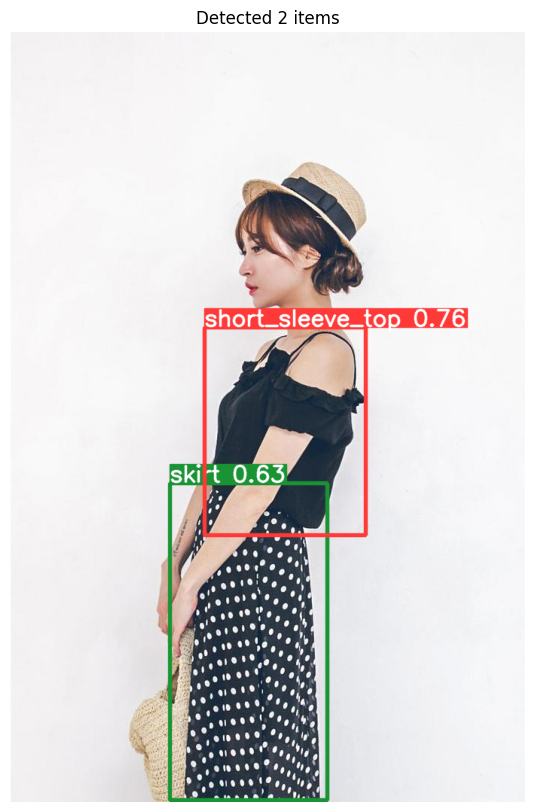

  short_sleeve_top: 0.76
  skirt: 0.63

012624.jpg

image 1/1 /scratch/shah.parin2/ClickTheLook/yolo_dataset/images/val/012624.jpg: 448x640 1 vest_dress, 48.6ms
Speed: 2.0ms preprocess, 48.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


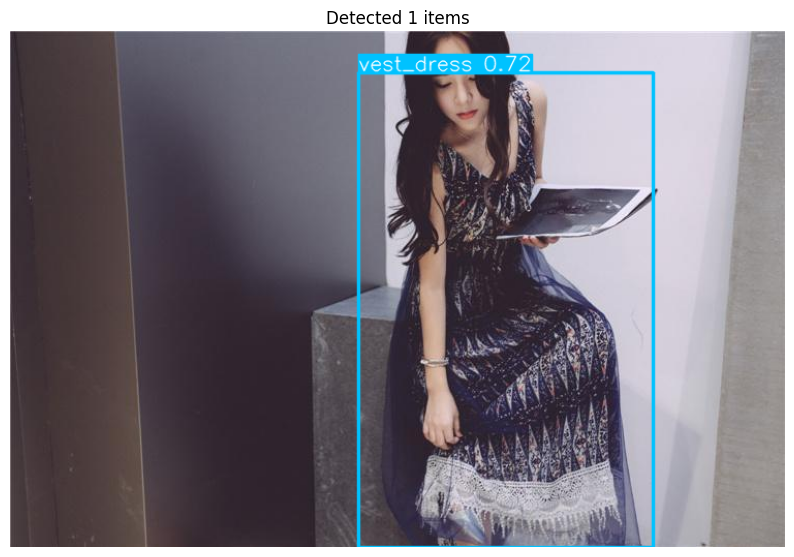

  vest_dress: 0.72

024837.jpg

image 1/1 /scratch/shah.parin2/ClickTheLook/yolo_dataset/images/val/024837.jpg: 640x544 1 long_sleeve_top, 1 trousers, 50.4ms
Speed: 2.3ms preprocess, 50.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 544)


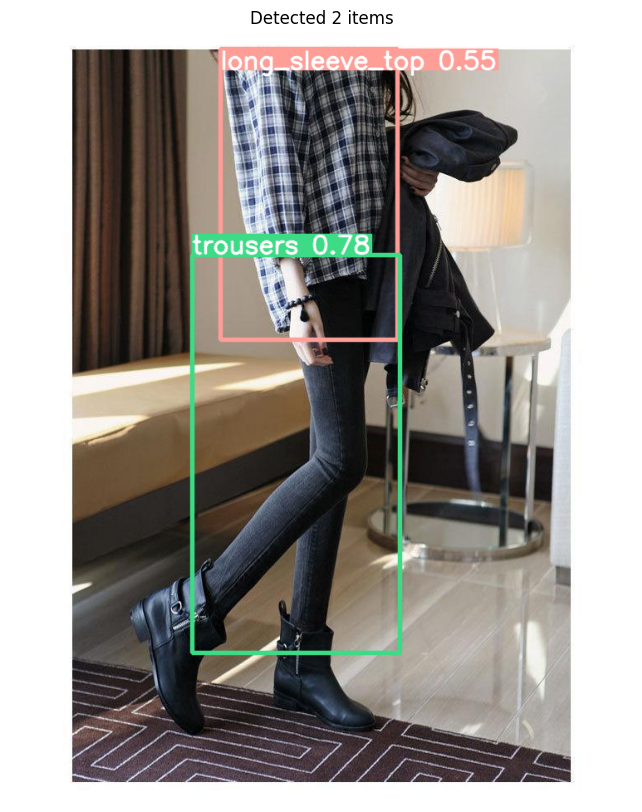

  trousers: 0.78
  long_sleeve_top: 0.55

029172.jpg

image 1/1 /scratch/shah.parin2/ClickTheLook/yolo_dataset/images/val/029172.jpg: 640x480 1 short_sleeve_top, 1 skirt, 40.2ms
Speed: 2.2ms preprocess, 40.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


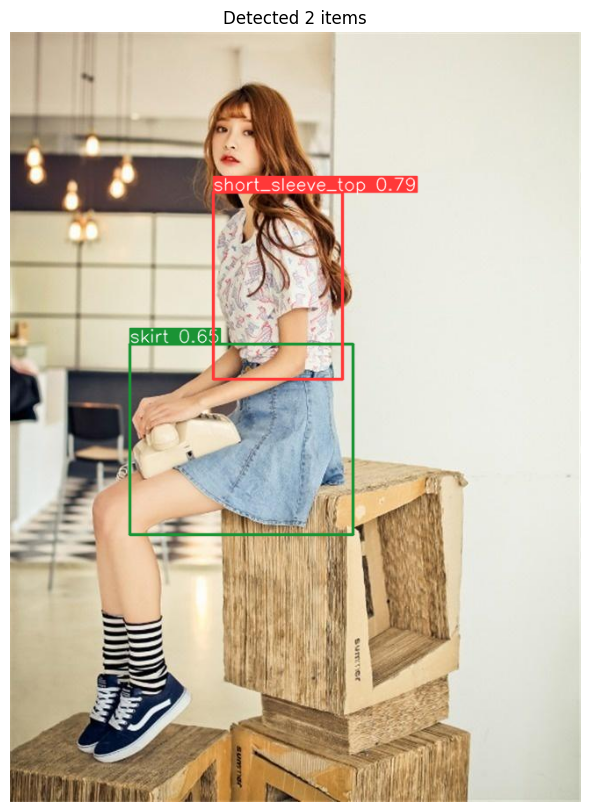

  short_sleeve_top: 0.79
  skirt: 0.65


In [23]:
vdir = os.path.join(YOLO_DATASET_DIR, "images", "val")
if os.path.exists(vdir):
    imgs = [f for f in os.listdir(vdir) if f.endswith((".jpg",".jpeg",".png"))]
    for p in random.sample([os.path.join(vdir,f) for f in imgs], min(4, len(imgs))):
        print(f"\n{'='*60}\n{os.path.basename(p)}")
        visualize_inference(run_inference(model, p))

---
## 9. Export & Save Weights

In [24]:
model.export(format='onnx', dynamic=True)
print("✓ ONNX export complete")

Ultralytics YOLOv8.2.0 🚀 Python-3.11.5 torch-2.0.1+cu118 CUDA:0 (Tesla P100-PCIE-12GB, 12194MiB)

PyTorch: starting from '/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX: export success ✅ 1.1s, saved as '/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.onnx' (11.5 MB)

Export complete (1.1s)
Results saved to /scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights
Predict:         yolo predict task=detect model=/scratch/shah.parin2/ClickTheLook/runs/yolov8_deepfashion2/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/scratch/shah.parin2/ClickTheLook/runs/yolov8_deep

---
## 10. Cleanup

In [25]:
# def cleanup_scratch(keep_weights=True):
#     if os.path.exists(YOLO_DATASET_DIR):
#         shutil.rmtree(YOLO_DATASET_DIR)
#         print(f"  ✓ Removed {YOLO_DATASET_DIR}")
#     if not keep_weights and os.path.exists(TRAINING_OUTPUT_DIR):
#         shutil.rmtree(TRAINING_OUTPUT_DIR)
#         print(f"  ✓ Removed {TRAINING_OUTPUT_DIR}")
#     gc.collect()
#     print(f"  Disk free: {get_disk_free_gb(SCRATCH_ROOT):.1f} GB")

---
## 11. Summary

In [26]:
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"\n📦 Source  : {SCRATCH_DATA_ROOT}")
print(f"📁 Scratch : {SCRATCH_ROOT}")
print(f"\n🔄 Memory Flow:")
print(f"   Conversion: CSV chunk (~50 MB) → RAM → convert → free → next")
print(f"   Images    : symlinked from source (zero extra disk space)")
print(f"   Training  : Disk → DataLoader → {TRAINING_CONFIG['batch']} imgs in GPU → train")
print(f"   ★ Full dataset NEVER in RAM at once")
print(f"\n🏋️  Model: {TRAINING_CONFIG['model']} | {TRAINING_CONFIG['epochs']} epochs")
print(f"   Batch: {TRAINING_CONFIG['batch']} | Device: {TRAINING_CONFIG['device']}")
print(f"\n🎯 Classes ({NUM_CLASSES}):")
for i in range(NUM_CLASSES): print(f"   {i}: {CATEGORIES[i+1]}")
print(f"\n📊 Best weights: {TRAINING_OUTPUT_DIR}/yolo8_deepfashion2/weights/best.pt")

PIPELINE SUMMARY

📦 Source  : /scratch/shah.parin2/DeepFashion2
📁 Scratch : /scratch/shah.parin2/ClickTheLook

🔄 Memory Flow:
   Conversion: CSV chunk (~50 MB) → RAM → convert → free → next
   Images    : symlinked from source (zero extra disk space)
   Training  : Disk → DataLoader → 96 imgs in GPU → train
   ★ Full dataset NEVER in RAM at once

🏋️  Model: yolov8n.pt | 13 epochs
   Batch: 96 | Device: 0

🎯 Classes (13):
   0: short_sleeve_top
   1: long_sleeve_top
   2: short_sleeve_outwear
   3: long_sleeve_outwear
   4: vest
   5: sling
   6: shorts
   7: trousers
   8: skirt
   9: short_sleeve_dress
   10: long_sleeve_dress
   11: vest_dress
   12: sling_dress

📊 Best weights: /scratch/shah.parin2/ClickTheLook/runs/yolo8_deepfashion2/weights/best.pt
